
#FORECASTING OIL PRICES USING TIME SERIES MODELS - ARIMA, LSTM & Prophet

ARIMA MODEL

1. IMPORTING LIBRARY

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
import warnings

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt
warnings.filterwarnings("ignore")

2. LOADING DATA

In [23]:
df = pd.read_csv("oil_prices_2426.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df.set_index("date", inplace=True)

price = df["price (dollars)"]

3. EDA

In [24]:
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

            price (dollars)
date                       
2024-09-21            32.10
2024-09-22            32.25
2024-09-23            31.07
2024-09-24            31.50
2024-09-25            32.21
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 500 entries, 2024-09-21 to 2026-02-02
Data columns (total 1 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   price (dollars)  500 non-null    float64
dtypes: float64(1)
memory usage: 7.8 KB
None
       price (dollars)
count       500.000000
mean         75.873980
std          42.912398
min          16.480000
25%          35.372500
50%          64.290000
75%         111.572500
max         158.780000
price (dollars)    0
dtype: int64


4. INTIAL PLOT

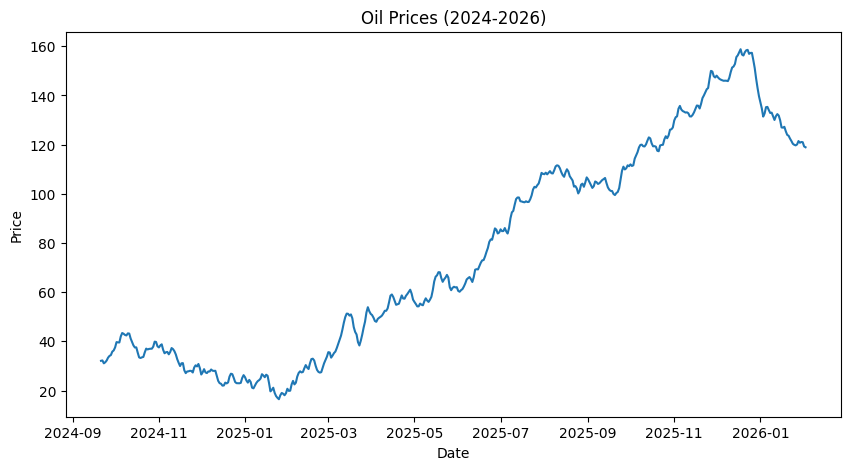

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(price)
plt.title("Oil Prices (2024-2026)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

5. TEST FOR NON-STATIONARY

ADF Statistic: -0.5462340182601538
p-value: 0.8826741397403087


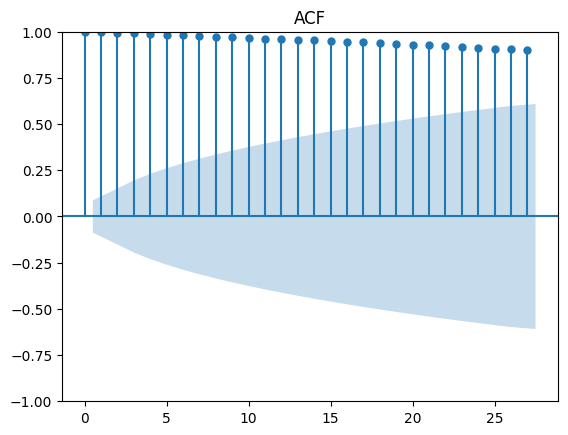

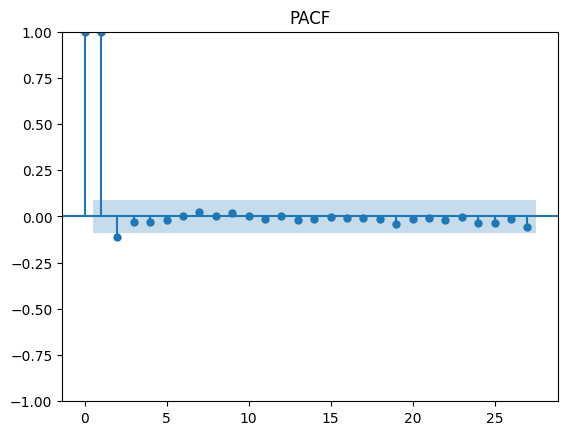

In [26]:
result = adfuller(price)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

plot_acf(price)
plt.title("ACF")
plt.show()

plot_pacf(price)
plt.title("PACF")
plt.show()

6. DIFFERENCING THE DATA

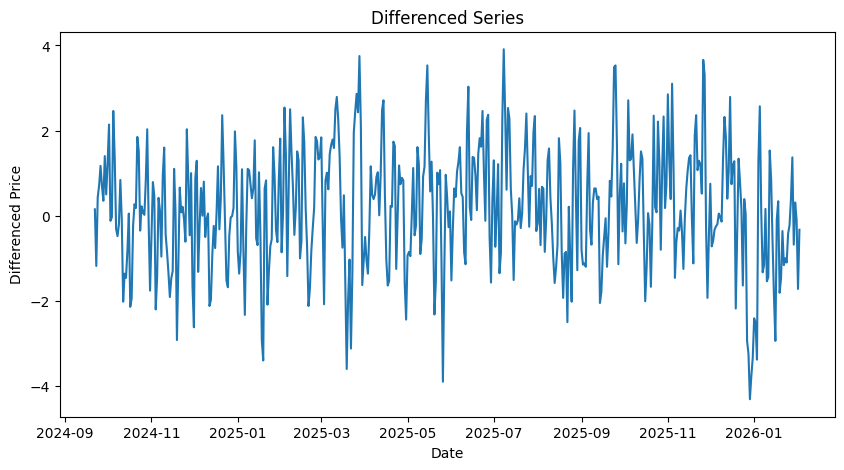

ADF- differenced: -4.541460173486698
p-value: 0.00016536459860957457


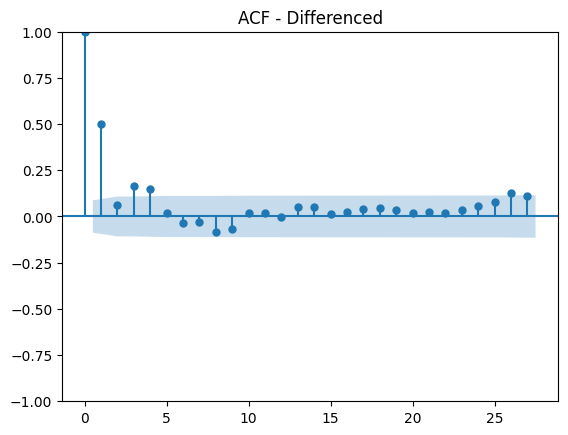

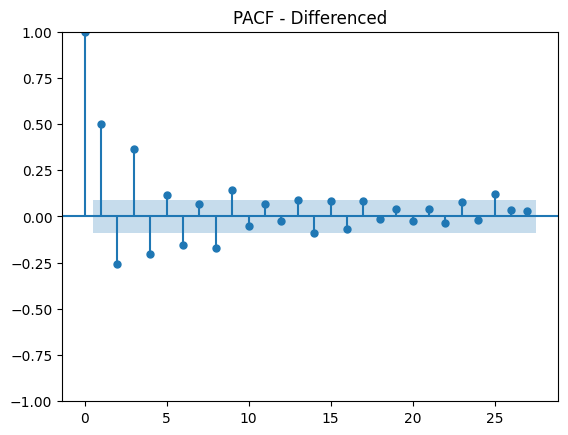

In [27]:
price_diff = price.diff().dropna()

plt.figure(figsize=(10, 5))
plt.plot(price_diff)
plt.title("Differenced Series")
plt.xlabel("Date")
plt.ylabel("Differenced Price")
plt.show()

result2 = adfuller(price_diff)
print("ADF- differenced:", result2[0])
print("p-value:", result2[1])

plot_acf(price_diff)
plt.title("ACF - Differenced")
plt.show()

plot_pacf(price_diff)
plt.title("PACF - Differenced")
plt.show()

7. TRAIN-TEST SPLITTING

In [28]:
train_size = int(len(price) * 0.8)

train = price[:train_size]
test = price[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 400
Test size: 100


8. SEARCHING BEST p,d,q USING AIC

In [30]:
p = range(0, 9)
d = range(0, 3)
q = range(0, 9)

results = []

for i, j, k in itertools.product(p, d, q):
    try:
        if j == 0:
            continue

        model = ARIMA(train, order=(i, j, k), trend="t")
        model_fit = model.fit()

        results.append([(i, j, k), model_fit.aic])

    except:
        continue

results = sorted(results, key=lambda x: x[1])

for r in results[:10]:
    print("Order:", r[0], "AIC:", r[1])

best_order = results[0][0]
print("\nBest ARIMA order:", best_order)
print("Best AIC:", results[0][1])

Order: (2, 1, 3) AIC: 1120.937469334926
Order: (3, 1, 3) AIC: 1123.066048700816
Order: (4, 1, 3) AIC: 1123.6916690368944
Order: (0, 1, 1) AIC: 1124.0896086944367
Order: (3, 1, 4) AIC: 1124.586242285612
Order: (2, 1, 5) AIC: 1124.6741323269587
Order: (0, 1, 4) AIC: 1125.2204425011414
Order: (0, 1, 5) AIC: 1125.5246304503944
Order: (3, 1, 1) AIC: 1125.5547064120292
Order: (5, 1, 3) AIC: 1125.685695952675

Best ARIMA order: (2, 1, 3)
Best AIC: 1120.937469334926


9. FITTING BEST MODEL

In [31]:
if best_order[1] == 0:
    model = ARIMA(train, order=best_order, trend="c")
else:
    model = ARIMA(train, order=best_order, trend="t")

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:        price (dollars)   No. Observations:                  400
Model:                 ARIMA(2, 1, 3)   Log Likelihood                -553.469
Date:                Thu, 12 Mar 2026   AIC                           1120.937
Time:                        06:10:43   BIC                           1148.860
Sample:                    09-21-2024   HQIC                          1131.996
                         - 10-25-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.2220      0.100      2.214      0.027       0.025       0.419
ar.L1          1.2644      0.034     36.950      0.000       1.197       1.331
ar.L2         -0.9141      0.033    -27.415      0.0

10. RESIDUAL DIAGNOSTICS

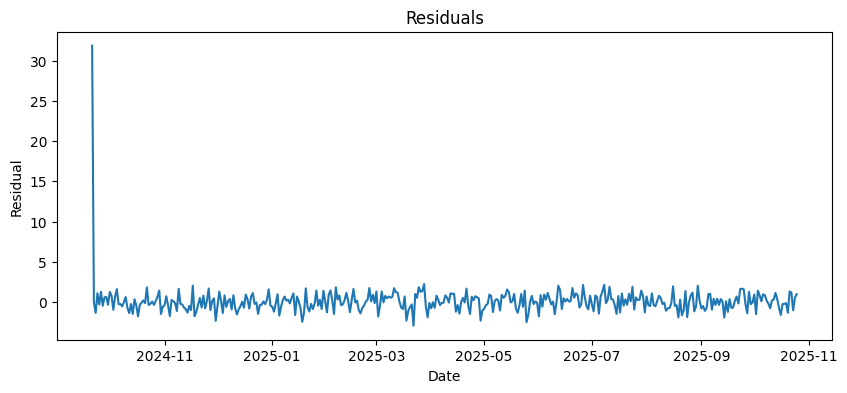

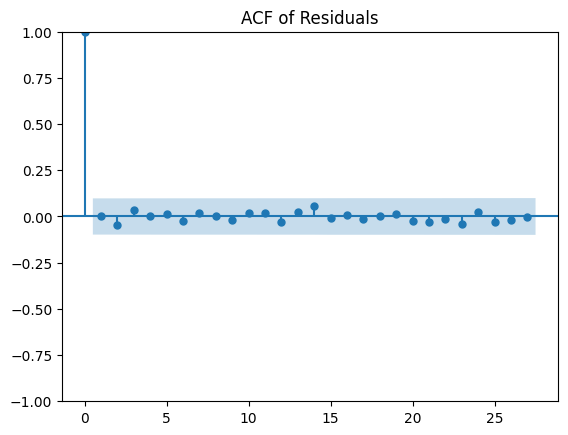

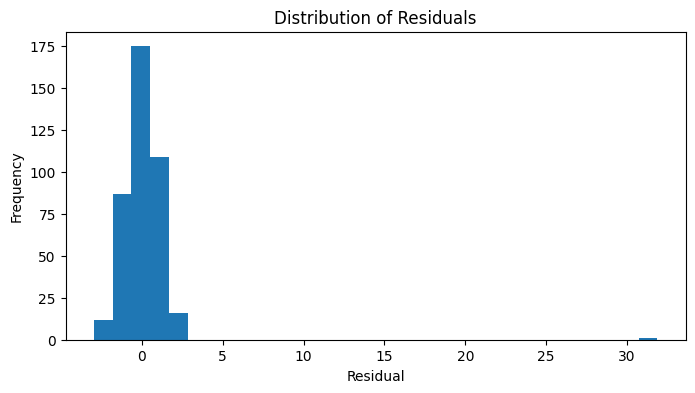

In [32]:
residuals = model_fit.resid

plt.figure(figsize=(10, 4))
plt.plot(residuals)
plt.title("Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.show()

plot_acf(residuals)
plt.title("ACF of Residuals")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=30)
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

11. 1-STEP AHEAD FORECAST USING WALK - FORWARD VALIDATION

In [33]:
history = list(train)
predictions = []

for t in range(len(test)):
    try:
        if best_order[1] == 0:
            model = ARIMA(history, order=best_order, trend="c")
        else:
            model = ARIMA(history, order=best_order, trend="t")

        model_fit = model.fit()
        yhat = model_fit.forecast(steps=1)
        predictions.append(yhat[0])

        history.append(test.iloc[t])

    except:
        predictions.append(history[-1])
        history.append(test.iloc[t])

predictions = pd.Series(predictions, index=test.index)

12. RMSE, MAE & MAPE

In [34]:
rmse = sqrt(mean_squared_error(test, predictions))
mae = mean_absolute_error(test, predictions)
mape = np.mean(np.abs((test - predictions) / test)) * 100

print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)

RMSE: 1.1202391902748154
MAE: 0.8780879750895646
MAPE: 0.6382216682468319


13. ACTUAL vs PREDICTED ON TEST SET

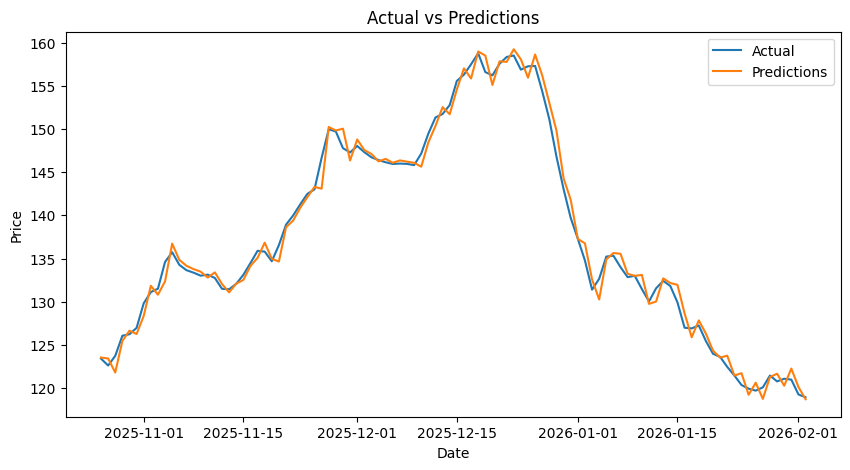

In [39]:
plt.figure(figsize=(10, 5))
plt.plot(test.index, test, label="Actual")
plt.plot(predictions.index, predictions, label="Predictions")
plt.title("Actual vs Predictions")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

14. FITTING MODEL

In [36]:
if best_order[1] == 0:
    model_full = ARIMA(price, order=best_order, trend="c")
else:
    model_full = ARIMA(price, order=best_order, trend="t")

model_full_fit = model_full.fit()


In [37]:
future = model_full_fit.get_forecast(steps=720)

forecast_values = future.predicted_mean
conf_int = future.conf_int()

15. FORECASTING 24 MONTHS FUTURE WITH CONFIDENCE INTERVALS

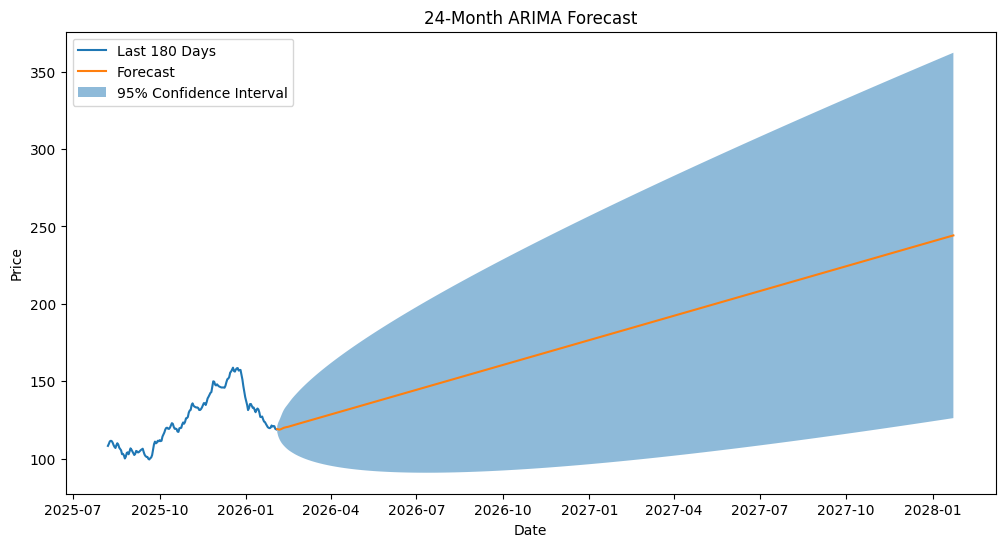

In [115]:
plt.figure(figsize=(12, 6))
plt.plot(price[-180:], label="Last 180 Days")
plt.plot(forecast_values, label="Forecast")
plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    alpha=0.5,
    label="95% Confidence Interval"
)
plt.title("24-Month ARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

LSTM MODEL

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense,Dropout


In [97]:
df = pd.read_csv("oil_prices_2426.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df.set_index("date", inplace=True)

price = df["price (dollars)"]

print(df.head())
print(df.describe())
print(df.isnull().sum())

            price (dollars)
date                       
2024-09-21            32.10
2024-09-22            32.25
2024-09-23            31.07
2024-09-24            31.50
2024-09-25            32.21
       price (dollars)
count       500.000000
mean         75.873980
std          42.912398
min          16.480000
25%          35.372500
50%          64.290000
75%         111.572500
max         158.780000
price (dollars)    0
dtype: int64


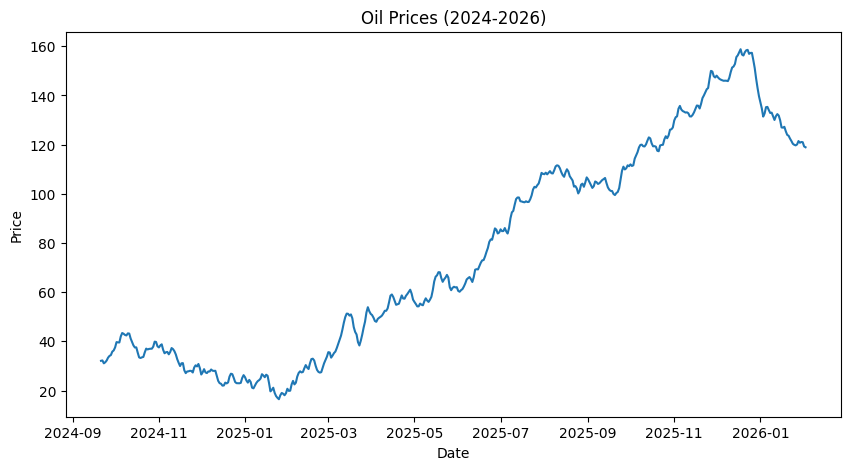

In [98]:
plt.figure(figsize=(10, 5))
plt.plot(price)
plt.title("Oil Prices (2024-2026)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

SCALING THE DATA

In [99]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_price = scaler.fit_transform(price.values.reshape(-1, 1))

CREATING SEQUENCES

In [100]:
time_step = 30

X = []
y = []

for i in range(time_step, len(scaled_price)):
    X.append(scaled_price[i-time_step:i, 0])
    y.append(scaled_price[i, 0])

X = np.array(X)
y = np.array(y)

X = X.reshape(X.shape[0], X.shape[1], 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (470, 30, 1)
y shape: (470,)


TRAIN - TEST SPLIT

In [101]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (376, 30, 1)
X_test shape: (94, 30, 1)


BUILDING THE MODEL

In [102]:
model = Sequential()
model.add(LSTM(50, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer="adam", loss="mean_squared_error")
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

TRAINING THE MODEL

In [103]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0344 - val_loss: 0.0173
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0042 - val_loss: 7.8840e-04
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0021 - val_loss: 4.6212e-04
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0018 - val_loss: 0.0012
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0016 - val_loss: 0.0014
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0019 - val_loss: 0.0014
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0020 - val_loss: 9.8122e-04
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0017 - val_loss: 0.0010
Epoch 9/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0015 - val_loss: 0.0011
Epoch 10/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0014 - val_loss: 0.0030
Epoch 11/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0017 - val_loss: 0.0020
Epoch 12/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - lo

TRAINING LOSS GRAPH

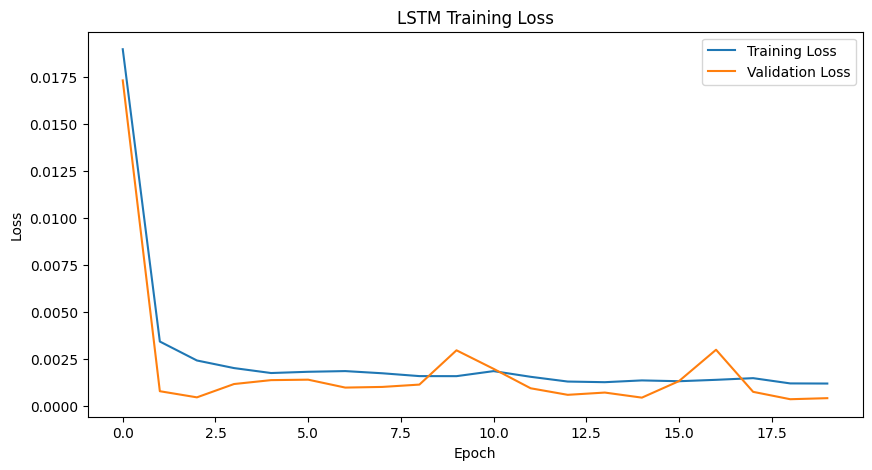

In [104]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

PREDICTIONS ON TEST SET

In [105]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


EVALUATION METRICS

In [106]:
rmse = sqrt(mean_squared_error(y_test_real, predictions))
mae = mean_absolute_error(y_test_real, predictions)
mape = np.mean(np.abs((y_test_real - predictions) / y_test_real)) * 100

print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)

RMSE: 5.170764585497611
MAE: 4.018641328202916
MAPE: 2.964339810967943


In [107]:
test_dates = price.index[time_step + train_size : time_step + train_size + len(y_test)]
print("Number of test dates:", len(test_dates))
print("Number of predictions:", len(predictions))

Number of test dates: 94
Number of predictions: 94


ACTUAL vs PREDICTED TEST VALUES

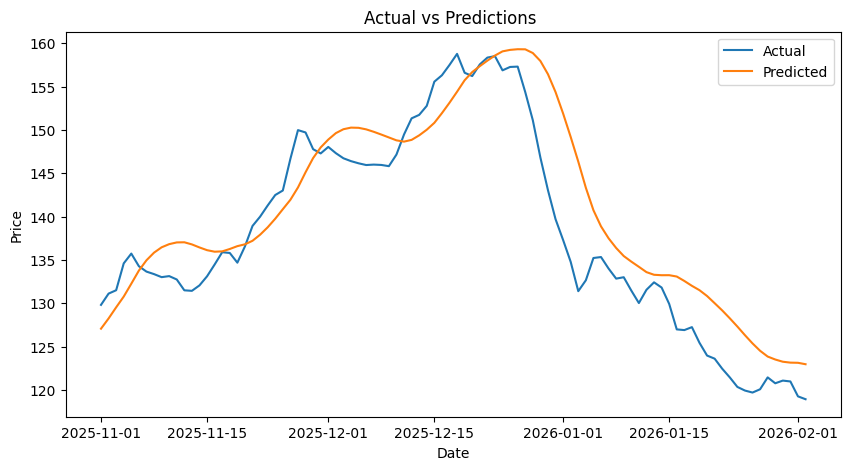

In [108]:
plt.figure(figsize=(10, 5))
plt.plot(test_dates, y_test_real, label="Actual")
plt.plot(test_dates, predictions, label="Predicted")
plt.title("Actual vs Predictions ")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

FORECASTING 24 MONTHS INTO FUTURE

In [109]:
future_days = 720
future_forecast = []

last_sequence = scaled_price[-time_step:]
current_input = last_sequence.reshape(1, time_step, 1)

for i in range(future_days):
    next_pred = model.predict(current_input, verbose=0)
    future_forecast.append(next_pred[0, 0])

    new_sequence = np.append(current_input[0, 1:, 0], next_pred[0, 0])
    current_input = new_sequence.reshape(1, time_step, 1)

future_forecast = np.array(future_forecast).reshape(-1, 1)
future_forecast = scaler.inverse_transform(future_forecast)

In [110]:
future_dates = pd.date_range(
    start=price.index[-1] + pd.Timedelta(days=1),
    periods=future_days,
    freq="D"
)

CREATING CONFIDENCE INTERVALS

In [111]:
errors = y_test_real.flatten() - predictions.flatten()
std_error = np.std(errors)

lower = future_forecast.flatten() - 1.96 * std_error
upper = future_forecast.flatten() + 1.96 * std_error

FORECASTING 24 MONTH GRAPH

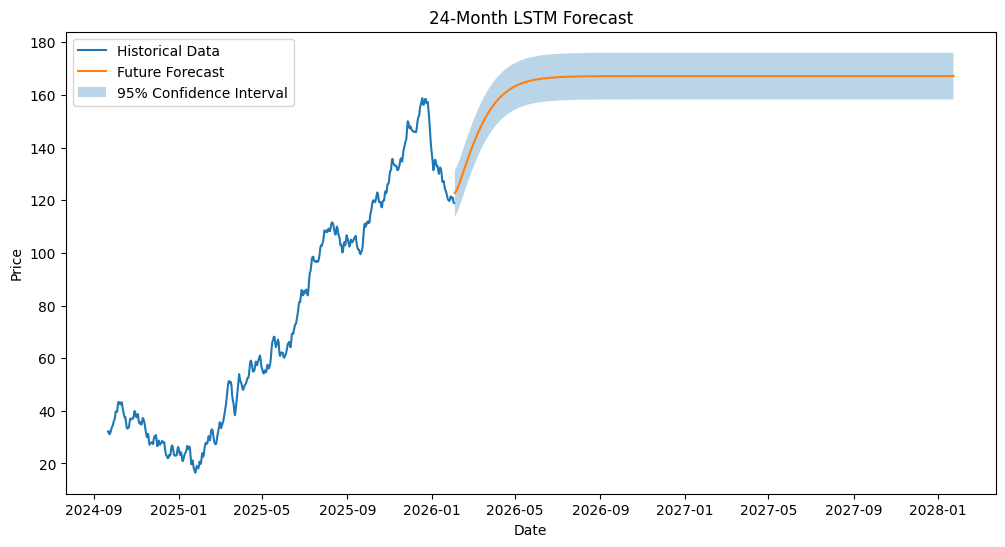

In [112]:
plt.figure(figsize=(12, 6))
plt.plot(price.index, price.values, label="Historical Data")
plt.plot(future_dates, future_forecast, label="Future Forecast")
plt.fill_between(future_dates, lower, upper, alpha=0.3, label="95% Confidence Interval")
plt.title("24-Month LSTM Forecast")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

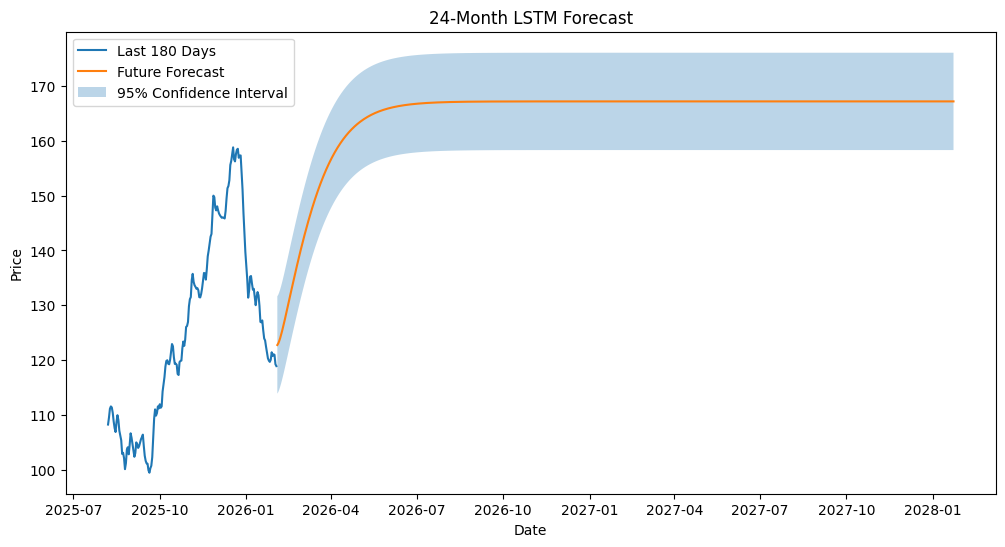

In [113]:
plt.figure(figsize=(12, 6))
plt.plot(price.index[-180:], price.values[-180:], label="Last 180 Days")
plt.plot(future_dates, future_forecast, label="Future Forecast")
plt.fill_between(future_dates, lower, upper, alpha=0.3, label="95% Confidence Interval")
plt.title("24-Month LSTM Forecast")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

PROPHET MODEL

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt

In [84]:
df = pd.read_csv("oil_prices_2426.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

df = df.rename(columns={
    "date": "ds",
    "price (dollars)": "y"
})

In [85]:
print(df.head())
print(df.describe())
print(df.isnull().sum())

          ds      y
0 2024-09-21  32.10
1 2024-09-22  32.25
2 2024-09-23  31.07
3 2024-09-24  31.50
4 2024-09-25  32.21
                        ds           y
count                  500  500.000000
mean   2025-05-28 12:00:00   75.873980
min    2024-09-21 00:00:00   16.480000
25%    2025-01-23 18:00:00   35.372500
50%    2025-05-28 12:00:00   64.290000
75%    2025-09-30 06:00:00  111.572500
max    2026-02-02 00:00:00  158.780000
std                    NaN   42.912398
ds    0
y     0
dtype: int64


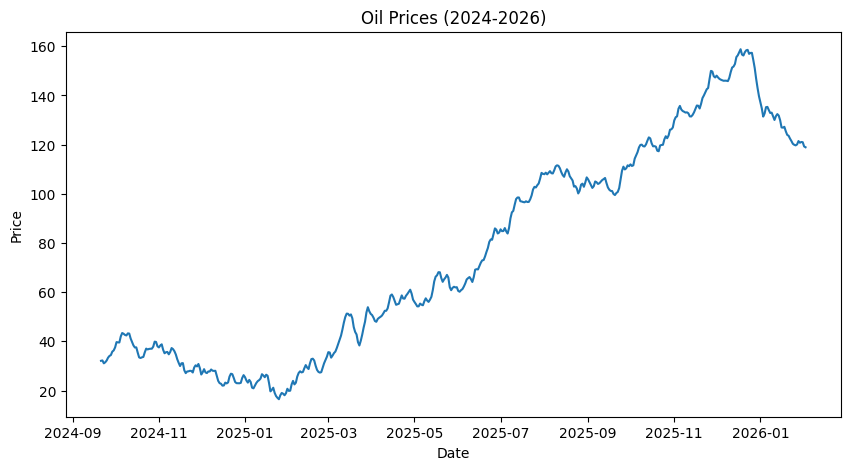

In [86]:
plt.figure(figsize=(10,5))
plt.plot(df["ds"], df["y"])
plt.title("Oil Prices (2024-2026)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

TRAIN - TEST SPLIT

In [87]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 400
Test size: 100


BUILDING PROPHET MODEL

In [88]:
model = Prophet(
    changepoint_prior_scale=0.05,
    interval_width=0.95,
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(train)

FORECAST TEST

In [89]:
future_test = model.make_future_dataframe(periods=len(test), freq="D")
forecast_test = model.predict(future_test)

pred_test = forecast_test.iloc[-len(test):][["ds","yhat","yhat_lower","yhat_upper"]]

EVALUATION METRICS

In [90]:
rmse = sqrt(mean_squared_error(test["y"], pred_test["yhat"]))
mae = mean_absolute_error(test["y"], pred_test["yhat"])
mape = np.mean(np.abs((test["y"].values - pred_test["yhat"].values) / test["y"].values)) * 100

print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)

RMSE: 17.912602733525663
MAE: 15.554962131048121
MAPE: 10.960190678921693


ACTUAL vs PREDICTED TEST

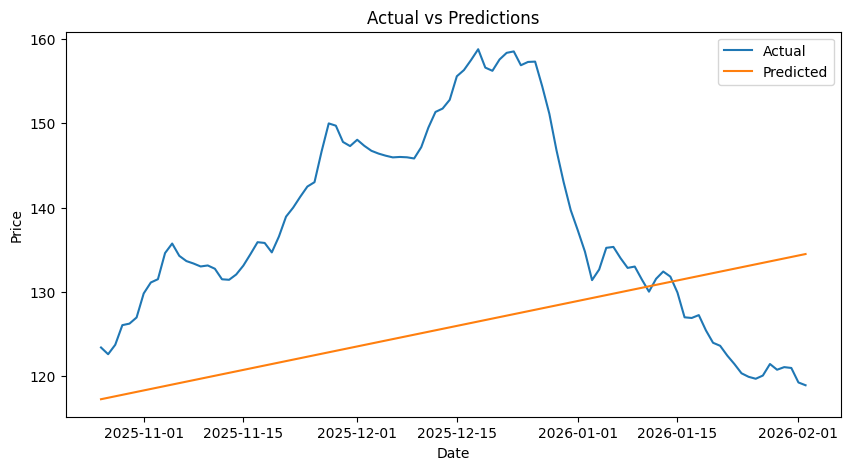

In [114]:
plt.figure(figsize=(10,5))
plt.plot(test["ds"], test["y"], label="Actual")
plt.plot(pred_test["ds"], pred_test["yhat"], label="Predicted")
plt.title("Actual vs Predictions")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

FITTING PROPHET MODEL

In [92]:
final_model = Prophet(
    changepoint_prior_scale=0.05,
    interval_width=0.95,
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False
)

final_model.fit(df)

FORECAST 24 MONTHS INTO FUTURE

In [93]:
future_24 = final_model.make_future_dataframe(periods=720, freq="D")
forecast_24 = final_model.predict(future_24)

future_only = forecast_24.iloc[-720:]

FORECAST 24 MONTHS GRAPH

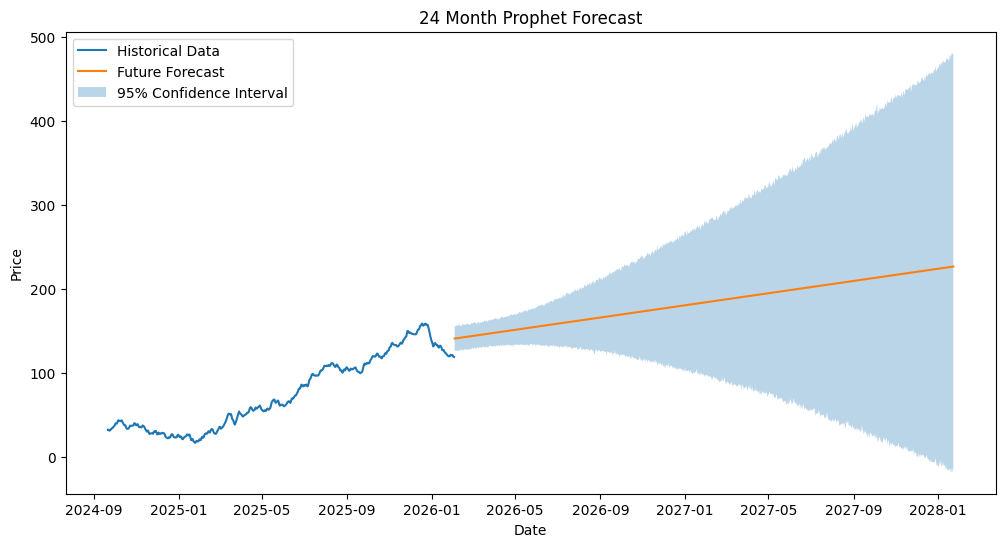

In [94]:
plt.figure(figsize=(12,6))
plt.plot(df["ds"], df["y"], label="Historical Data")
plt.plot(future_only["ds"], future_only["yhat"], label="Future Forecast")
plt.fill_between(
    future_only["ds"],
    future_only["yhat_lower"],
    future_only["yhat_upper"],
    alpha=0.3,
    label="95% Confidence Interval"
)
plt.title("24 Month Prophet Forecast")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

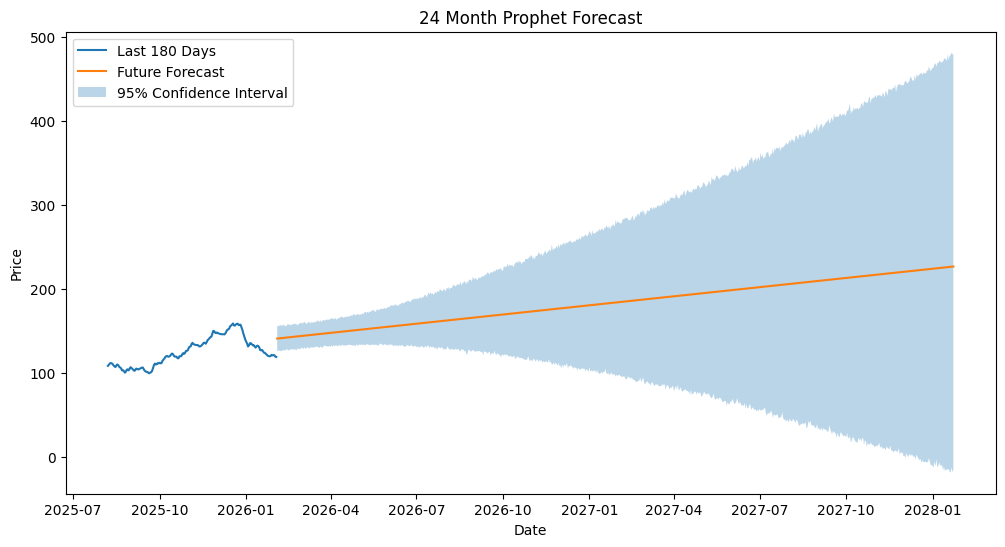

In [95]:
plt.figure(figsize=(12,6))
plt.plot(df["ds"].iloc[-180:], df["y"].iloc[-180:], label="Last 180 Days")
plt.plot(future_only["ds"], future_only["yhat"], label="Future Forecast")
plt.fill_between(
    future_only["ds"],
    future_only["yhat_lower"],
    future_only["yhat_upper"],
    alpha=0.3,
    label="95% Confidence Interval"
)
plt.title("24 Month Prophet Forecast")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()